# H₂ ML-QEM: Comprehensive Statistical Analysis & Improvements

1. **Multi-seed MLP training** (5 seeds, 1000 epochs)
2. **Overfitting check** for RF and MLP
3. **Bootstrap confidence intervals** on all MAE values (unmitigated, RF, MLP)
4. **Additional metrics** (R², max error, 90th percentile) for all methods
5. **RF vs MLP significance test** (paired bootstrap)
6. **MLP training diagnostics** (loss curves)
7. **Learned correction function** visualization
8. **Predicted vs ideal** scatter plots
9. **Residual analysis** (vs noisy value, vs ideal, distribution)
10. **Per-observable breakdown** with bootstrap CIs
11. **Feature ablation study** (progressive feature addition)

Data efficiency analysis is in the separate  notebook.

**Data files needed**: ideal_data.npy, noisy_data.npy, theta_samples.npy, rf_mlqem.joblib, dataset_meta.json

## 0. Imports and Data Loading

In [7]:
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
    'figure.dpi': 150,
})
COLORS = {'unm': '#e74c3c', 'rf': '#3498db', 'ideal': '#2ecc71', 'mlp': '#9b59b6'}
print('All imports OK')

All imports OK


In [8]:
# ── Load data ──
ideal_data = np.load('ideal_data.npy')
noisy_data = np.load('noisy_data.npy')
theta_samples = np.load('theta_samples.npy')

try:
    rf = joblib.load('h2_rf_mlqem.joblib')
except FileNotFoundError:
    rf = joblib.load('rf_mlqem.joblib')

with open('dataset_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
N_QUBITS = 2
ALL_OBS = [1, 2, 3, 4]
N_TRAIN = 1800

print(f'Data: {ideal_data.shape[0]} samples, {ideal_data.shape[1]} Pauli terms')
print(f'RF model: {rf.n_estimators} trees, {rf.n_features_in_} features')

Data: 2000 samples, 5 Pauli terms
RF model: 100 trees, 13 features


In [9]:
# ── Feature construction ──
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeLimaV2

backend = FakeLimaV2()
props = backend.properties()
qubit_props = {}
for q in range(N_QUBITS):
    qubit_props[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

def pauli_to_symplectic(label):
    p = Pauli(label)
    return np.concatenate([p.x.astype(int), p.z.astype(int)])

SYMPLECTIC = {label: pauli_to_symplectic(label) for label in PAULI_LABELS}
N_2Q, N_SX = 3, 8

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([qubit_props[q]['T1']*active, qubit_props[q]['T2']*active, qubit_props[q]['readout_error']*active])
    return feats

def build_features(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        noise_feats = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp, N_2Q, N_SX, *noise_feats])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

X_train, y_train = build_features(noisy_data[:N_TRAIN], ideal_data[:N_TRAIN], ALL_OBS)
X_test, y_test = build_features(noisy_data[N_TRAIN:], ideal_data[N_TRAIN:], ALL_OBS)

# RF predictions
train_pred_rf = rf.predict(X_train)
test_pred_rf = rf.predict(X_test)
baseline = X_test[:, 0]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (7200, 13), Test: (800, 13)


## 1. Train MLP (5 seeds, 1000 epochs)

Train 5 MLPs with different random seeds to account for initialization sensitivity.

In [10]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)
    def count_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

# 80/20 train/validation split
n_val = int(0.2 * len(X_train))
idx = np.random.RandomState(42).permutation(len(X_train))
val_idx, train_idx = idx[:n_val], idx[n_val:]

X_tr, y_tr = X_train[train_idx], y_train[train_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
X_te_sc = scaler.transform(X_test)

Xt = torch.tensor(X_tr_sc, dtype=torch.float32)
yt = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
Xv = torch.tensor(X_val_sc, dtype=torch.float32)
Xte = torch.tensor(X_te_sc, dtype=torch.float32)

N_MLP_SEEDS = 5
mlp_maes_all = []
mlp_preds_all = []
all_train_hists = []
all_val_hists = []

for seed in range(N_MLP_SEEDS):
    torch.manual_seed(seed)
    model = MLP(X_train.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.HuberLoss()

    best_val_mae, best_state, no_imp = float('inf'), None, 0
    t_hist, v_hist = [], []

    for epoch in range(1000):
        model.train()
        opt.zero_grad(); crit(model(Xt), yt).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr_mae = mean_absolute_error(y_tr, model(Xt).numpy().ravel())
            vl_mae = mean_absolute_error(y_val, model(Xv).numpy().ravel())
        t_hist.append(tr_mae)
        v_hist.append(vl_mae)
        if vl_mae < best_val_mae - 1e-6:
            best_val_mae = vl_mae
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= 25: break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds = model(Xte).numpy().ravel()

    seed_mae = mean_absolute_error(y_test, preds)
    mlp_maes_all.append(seed_mae)
    mlp_preds_all.append(preds)
    all_train_hists.append(t_hist)
    all_val_hists.append(v_hist)
    print(f'  Seed {seed}: MAE = {seed_mae:.4f}, stopped at epoch {len(t_hist)}')

# Use median seed for comparisons
median_idx = np.argsort(mlp_maes_all)[N_MLP_SEEDS // 2]
mlp_test_pred = mlp_preds_all[median_idx]
train_hist = all_train_hists[median_idx]
val_hist = all_val_hists[median_idx]

# Also compute MLP train prediction for overfitting check (median seed)
torch.manual_seed(median_idx)
model_final = MLP(X_train.shape[1])
model_final.load_state_dict(best_state)  # reuse last best_state
model_final.eval()
X_tr_all_sc = scaler.transform(X_train)
with torch.no_grad():
    train_pred_mlp = model_final(torch.tensor(X_tr_all_sc, dtype=torch.float32)).numpy().ravel()

mlp_mae_mean = np.mean(mlp_maes_all)
mlp_mae_std = np.std(mlp_maes_all)

print(f'\nMLP across {N_MLP_SEEDS} seeds: {mlp_mae_mean:.4f} ± {mlp_mae_std:.4f}')
print(f'Individual: {[f"{m:.4f}" for m in mlp_maes_all]}')
print(f'Using median seed {median_idx} (MAE={mlp_maes_all[median_idx]:.4f}) for plots')

  Seed 0: MAE = 0.0077, stopped at epoch 719
  Seed 1: MAE = 0.0077, stopped at epoch 963
  Seed 2: MAE = 0.0076, stopped at epoch 668
  Seed 3: MAE = 0.0074, stopped at epoch 925
  Seed 4: MAE = 0.0077, stopped at epoch 866

MLP across 5 seeds: 0.0076 ± 0.0001
Individual: ['0.0077', '0.0077', '0.0076', '0.0074', '0.0077']
Using median seed 4 (MAE=0.0077) for plots


## 2. Overfitting Check (Train vs Test MAE)

Compare train-test gap for both RF and MLP.

In [11]:
train_mae_rf = mean_absolute_error(y_train, train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, test_pred_rf)

train_mae_mlp = mean_absolute_error(y_train, train_pred_mlp)
test_mae_mlp = mean_absolute_error(y_test, mlp_test_pred)

print(f'{"":20} {"Train MAE":>12} {"Test MAE":>12} {"Ratio":>8}')
print('-' * 54)
print(f'{"RF":<20} {train_mae_rf:>12.6f} {test_mae_rf:>12.6f} {test_mae_rf/train_mae_rf:>7.2f}x')
print(f'{"MLP (median seed)":<20} {train_mae_mlp:>12.6f} {test_mae_mlp:>12.6f} {test_mae_mlp/train_mae_mlp:>7.2f}x')
print()
print('RF shows moderate overfitting (typical for default settings).')
print('MLP gap indicates how well the network generalizes.')

                        Train MAE     Test MAE    Ratio
------------------------------------------------------
RF                       0.003366     0.008386    2.49x
MLP (median seed)        0.007375     0.007653    1.04x

RF shows moderate overfitting (typical for default settings).
MLP gap indicates how well the network generalizes.


## 3. Bootstrap Confidence Intervals

95% bootstrap CIs for unmitigated, RF, and MLP (median seed).

In [38]:
rng = np.random.default_rng(42)

def bootstrap_mae_ci(true, pred, n_boot=1000, ci=95):
    errors = np.abs(true - pred)
    boot_maes = np.array([
        errors[rng.choice(len(errors), size=len(errors), replace=True)].mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(boot_maes, (100 - ci) / 2)
    hi = np.percentile(boot_maes, 100 - (100 - ci) / 2)
    return errors.mean(), lo, hi, boot_maes

mae_unm, lo_unm, hi_unm, boot_unm = bootstrap_mae_ci(y_test, baseline)
mae_rf, lo_rf, hi_rf, boot_rf = bootstrap_mae_ci(y_test, test_pred_rf)
mae_mlp, lo_mlp, hi_mlp, boot_mlp = bootstrap_mae_ci(y_test, mlp_test_pred)

print('Expectation Value MAE (95% Bootstrap CIs):')
print(f'  Unmitigated: {mae_unm:.4f}  [{lo_unm:.4f}, {hi_unm:.4f}]')
print(f'  RF:          {mae_rf:.4f}  [{lo_rf:.4f}, {hi_rf:.4f}]')
print(f'  MLP:         {mae_mlp:.4f}  [{lo_mlp:.4f}, {hi_mlp:.4f}]  (median seed)')
print(f'  MLP mean±std:{mlp_mae_mean:.4f} ± {mlp_mae_std:.4f}  (across {N_MLP_SEEDS} seeds)')

# Energy MAE
coeffs = np.array(PAULI_COEFFS)
E_ideal = ideal_data[N_TRAIN:] @ coeffs
E_noisy = noisy_data[N_TRAIN:] @ coeffs

# RF corrected energy
rf_corrected = noisy_data[N_TRAIN:].copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = 200
    feats = np.column_stack([
        noisy_data[N_TRAIN:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX), np.tile(nf, (N, 1)),
    ])
    rf_corrected[:, obs_idx] = rf.predict(feats)
E_rf = rf_corrected @ coeffs

# MLP corrected energy
mlp_corrected = noisy_data[N_TRAIN:].copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = 200
    feats = np.column_stack([
        noisy_data[N_TRAIN:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX), np.tile(nf, (N, 1)),
    ]).astype(np.float32)
    feats_sc = scaler.transform(feats)
    model_final.eval()
    with torch.no_grad():
        mlp_corrected[:, obs_idx] = model_final(torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()
E_mlp = mlp_corrected @ coeffs

e_mae_unm, e_lo_unm, e_hi_unm, _ = bootstrap_mae_ci(E_ideal, E_noisy)
e_mae_rf, e_lo_rf, e_hi_rf, _ = bootstrap_mae_ci(E_ideal, E_rf)
e_mae_mlp, e_lo_mlp, e_hi_mlp, _ = bootstrap_mae_ci(E_ideal, E_mlp)

print(f'\nEnergy MAE (95% Bootstrap CIs):')
print(f'  Unmitigated: {e_mae_unm:.5f} Ha  [{e_lo_unm:.5f}, {e_hi_unm:.5f}]')
print(f'  RF:          {e_mae_rf:.5f} Ha  [{e_lo_rf:.5f}, {e_hi_rf:.5f}]')
print(f'  MLP:         {e_mae_mlp:.5f} Ha  [{e_lo_mlp:.5f}, {e_hi_mlp:.5f}]')

Expectation Value MAE (95% Bootstrap CIs):
  Unmitigated: 0.0349  [0.0333, 0.0365]
  RF:          0.0084  [0.0079, 0.0088]
  MLP:         0.0077  [0.0072, 0.0081]  (median seed)
  MLP mean±std:0.0076 ± 0.0001  (across 5 seeds)

Energy MAE (95% Bootstrap CIs):
  Unmitigated: 0.01555 Ha  [0.01430, 0.01681]
  RF:          0.00461 Ha  [0.00406, 0.00518]
  MLP:         0.00402 Ha  [0.00354, 0.00455]


## 4. Additional Metrics (R², Max Error, 90th Percentile)

In [39]:
print(f'{"Metric":<20} {"Unmitigated":>14} {"RF":>14} {"MLP":>14}')
print('-' * 64)
for metric_name, func in [
    ('MAE', lambda t, p: np.abs(t - p).mean()),
    ('Max error', lambda t, p: np.abs(t - p).max()),
    ('90th pct error', lambda t, p: np.percentile(np.abs(t - p), 90)),
    ('R²', lambda t, p: r2_score(t, p)),
]:
    v_unm = func(y_test, baseline)
    v_rf = func(y_test, test_pred_rf)
    v_mlp = func(y_test, mlp_test_pred)
    print(f'{metric_name:<20} {v_unm:>14.6f} {v_rf:>14.6f} {v_mlp:>14.6f}')

Metric                  Unmitigated             RF            MLP
----------------------------------------------------------------
MAE                        0.034907       0.008386       0.007653
Max error                  0.093526       0.044254       0.042878
90th pct error             0.071545       0.018305       0.015620
R²                         0.994687       0.999651       0.999716


## 5. RF vs MLP Significance Test (paired bootstrap)

In [40]:
diff_boot = boot_mlp - boot_rf
ci_lower = np.percentile(diff_boot, 2.5)
ci_upper = np.percentile(diff_boot, 97.5)

print(f'RF MAE:  {mae_rf:.4f}  [{lo_rf:.4f}, {hi_rf:.4f}]')
print(f'MLP MAE: {mae_mlp:.4f}  [{lo_mlp:.4f}, {hi_mlp:.4f}]  (median seed)')
print(f'\nDifference (MLP - RF): {diff_boot.mean():.4f}  [{ci_lower:.4f}, {ci_upper:.4f}]')

if ci_lower > 0:
    print('Significant at 95%: Yes — RF is significantly better')
elif ci_upper < 0:
    print('Significant at 95%: Yes — MLP is significantly better')
else:
    print('Significant at 95%: No — difference not significant')

RF MAE:  0.0084  [0.0079, 0.0088]
MLP MAE: 0.0077  [0.0072, 0.0081]  (median seed)

Difference (MLP - RF): -0.0007  [-0.0013, -0.0001]
Significant at 95%: Yes — MLP is significantly better


## 6. Learned Correction Function

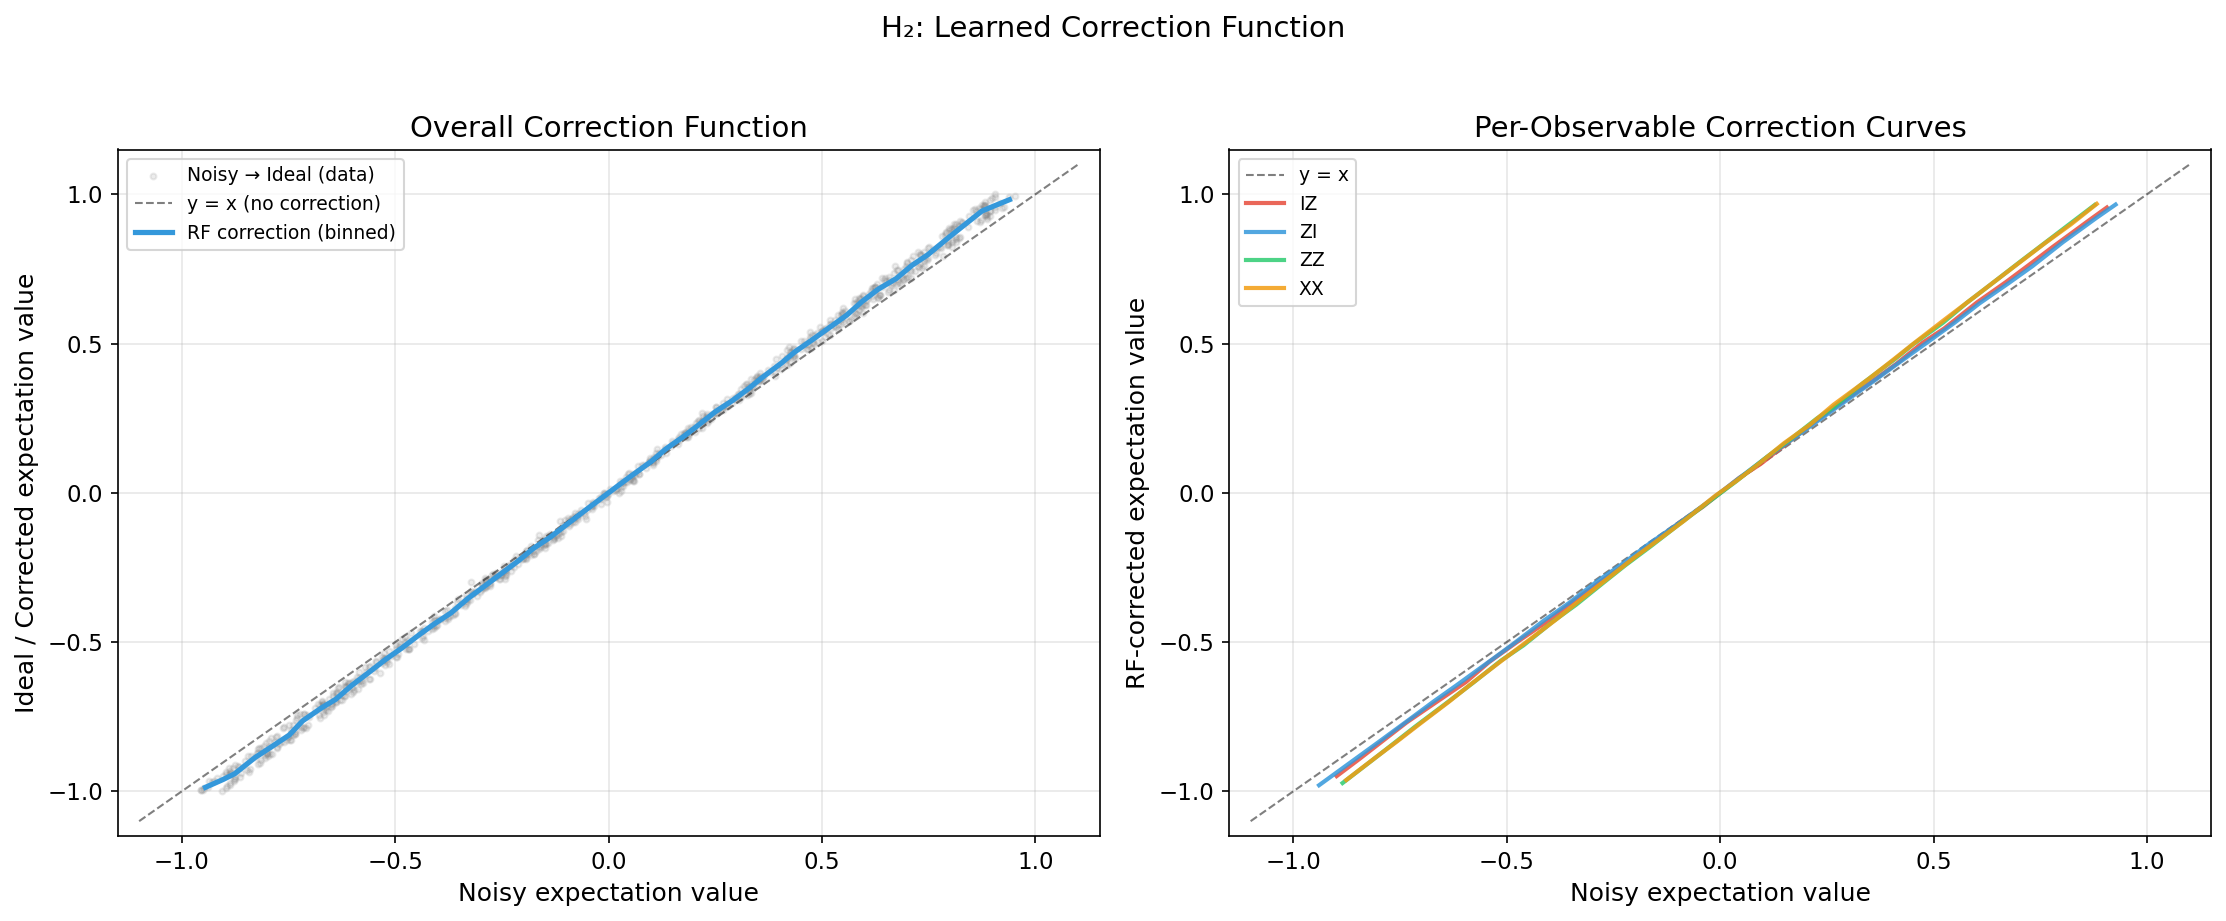

If the per-observable curves differ, the symplectic encoding is enabling
specialized correction — reconciling the ablation finding with the 1D interpretation.


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: overall correction function (all observables pooled) ──
ax = axes[0]
ax.scatter(baseline, y_test, alpha=0.15, s=8, color='gray', label='Noisy → Ideal (data)', zorder=1)
ax.plot([-1.1, 1.1], [-1.1, 1.1], 'k--', linewidth=1, alpha=0.5, label='y = x (no correction)')

n_bins = 50
bin_edges = np.linspace(baseline.min() - 0.01, baseline.max() + 0.01, n_bins + 1)
bin_centers, bin_rf_means = [], []
for k in range(n_bins):
    mask = (baseline >= bin_edges[k]) & (baseline < bin_edges[k+1])
    if mask.sum() > 2:
        bin_centers.append(baseline[mask].mean())
        bin_rf_means.append(test_pred_rf[mask].mean())

ax.plot(bin_centers, bin_rf_means, color=COLORS['rf'], linewidth=2.5, label='RF correction (binned)', zorder=3)
ax.set_xlabel('Noisy expectation value')
ax.set_ylabel('Ideal / Corrected expectation value')
ax.set_title('Overall Correction Function')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)

# ── Right: per-observable correction curves ──
ax = axes[1]
ax.plot([-1.1, 1.1], [-1.1, 1.1], 'k--', linewidth=1, alpha=0.5, label='y = x')

obs_colors = {'IZ': '#e74c3c', 'ZI': '#3498db', 'ZZ': '#2ecc71', 'XX': '#f39c12'}
N_test = 200  # 200 theta values in test set

for j, obs_idx in enumerate(ALL_OBS):
    label = PAULI_LABELS[obs_idx]
    # Extract this observable's noisy and RF-corrected values
    noisy_obs = noisy_data[N_TRAIN:, obs_idx]
    ideal_obs = ideal_data[N_TRAIN:, obs_idx]
    
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    feats = np.column_stack([
        noisy_obs, np.tile(symp, (N_test, 1)),
        np.full((N_test, 1), N_2Q), np.full((N_test, 1), N_SX), np.tile(nf, (N_test, 1)),
    ]).astype(np.float32)
    rf_corr_obs = rf.predict(feats)
    
    # Bin and average for smooth curve
    sort_idx = np.argsort(noisy_obs)
    n_b = 30
    be = np.linspace(noisy_obs.min() - 0.01, noisy_obs.max() + 0.01, n_b + 1)
    bc, bm = [], []
    for k in range(n_b):
        m = (noisy_obs >= be[k]) & (noisy_obs < be[k+1])
        if m.sum() > 2:
            bc.append(noisy_obs[m].mean())
            bm.append(rf_corr_obs[m].mean())
    
    ax.plot(bc, bm, color=obs_colors[label], linewidth=2, label=f'{label}', alpha=0.85)

ax.set_xlabel('Noisy expectation value')
ax.set_ylabel('RF-corrected expectation value')
ax.set_title('Per-Observable Correction Curves')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)

plt.suptitle('H₂: Learned Correction Function', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('h2_correction_function.png', dpi=150, bbox_inches='tight')
plt.show()

print('If the per-observable curves differ, the symplectic encoding is enabling')
print('specialized correction — reconciling the ablation finding with the 1D interpretation.')

## 7. Predicted vs Ideal Scatter Plot

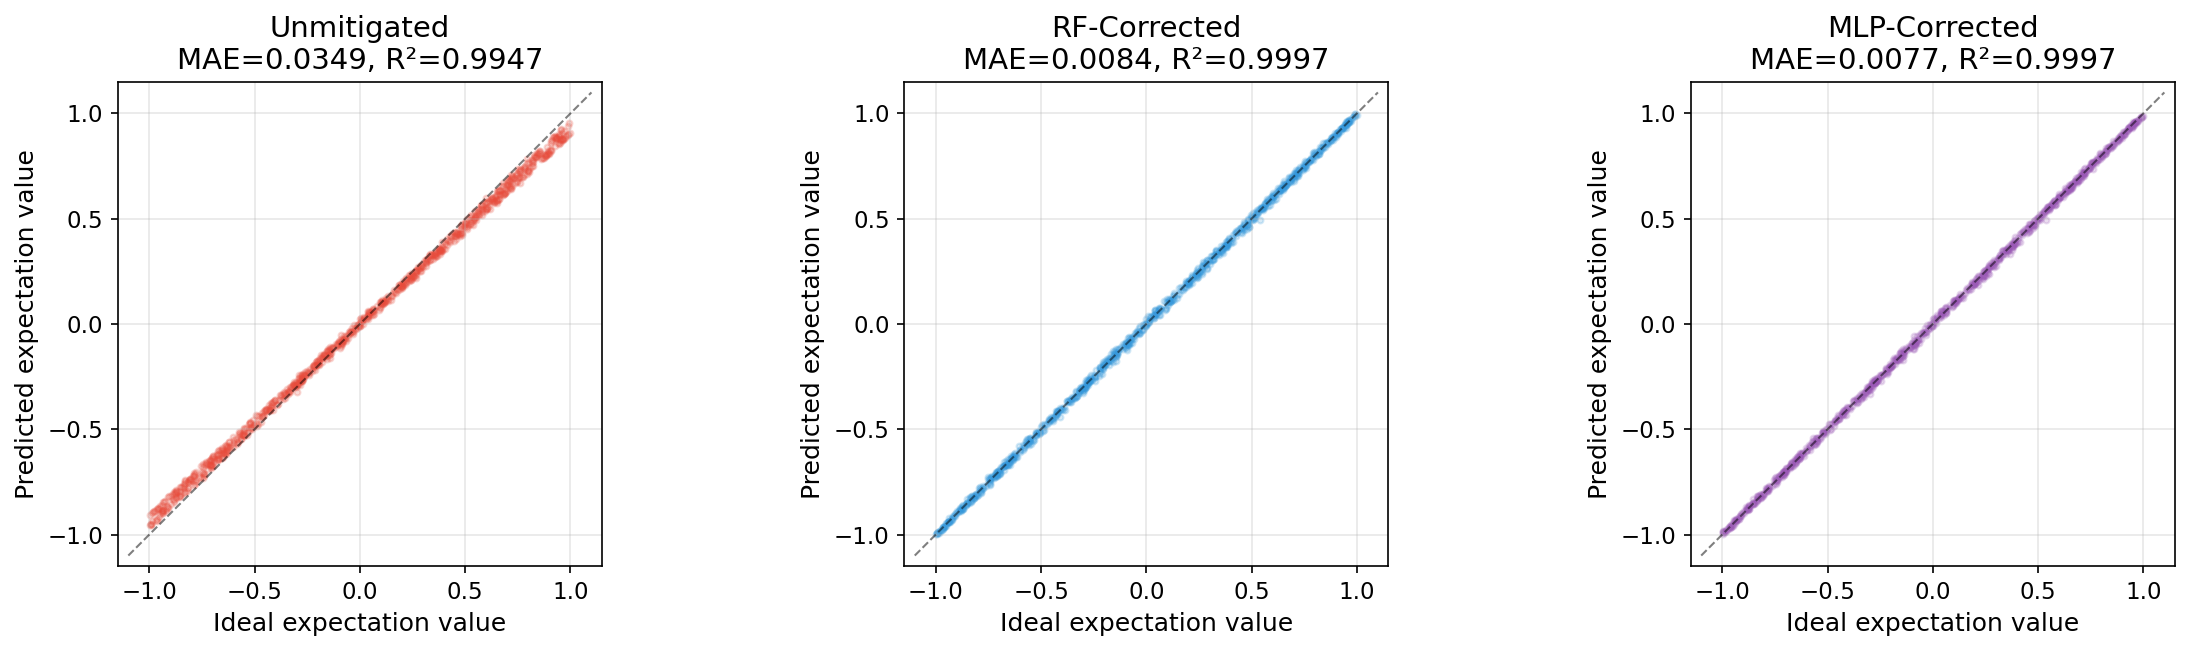

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, pred, name, color in [
    (axes[0], baseline, 'Unmitigated', COLORS['unm']),
    (axes[1], test_pred_rf, 'RF-Corrected', COLORS['rf']),
    (axes[2], mlp_test_pred, 'MLP-Corrected', COLORS['mlp']),
]:
    ax.scatter(y_test, pred, alpha=0.2, s=8, color=color)
    ax.plot([-1.1, 1.1], [-1.1, 1.1], 'k--', linewidth=1, alpha=0.5)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    ax.set_xlabel('Ideal expectation value')
    ax.set_ylabel('Predicted expectation value')
    ax.set_title(f'{name}\nMAE={mae:.4f}, R²={r2:.4f}')
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('h2_predicted_vs_ideal.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Residual Analysis

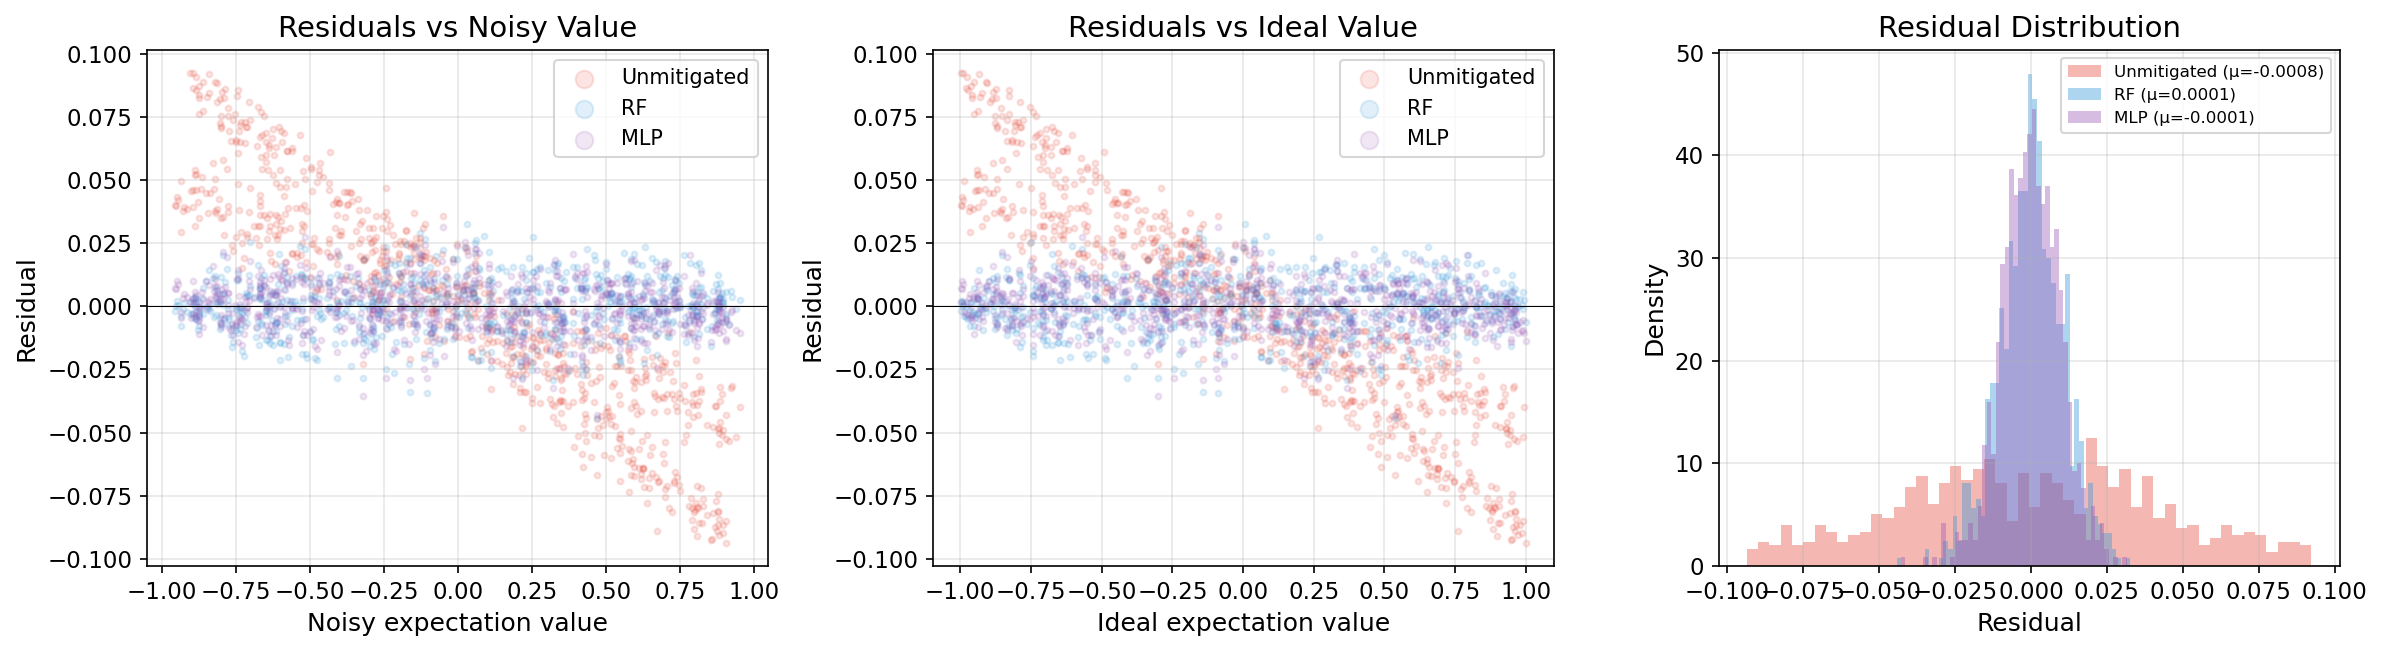

In [43]:
residuals_rf = test_pred_rf - y_test
residuals_mlp = mlp_test_pred - y_test
residuals_unm = baseline - y_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.scatter(baseline, residuals_unm, alpha=0.15, s=8, color=COLORS['unm'], label='Unmitigated')
ax.scatter(baseline, residuals_rf, alpha=0.15, s=8, color=COLORS['rf'], label='RF')
ax.scatter(baseline, residuals_mlp, alpha=0.15, s=8, color=COLORS['mlp'], label='MLP')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Noisy expectation value'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Noisy Value'); ax.legend(markerscale=3); ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(y_test, residuals_unm, alpha=0.15, s=8, color=COLORS['unm'], label='Unmitigated')
ax.scatter(y_test, residuals_rf, alpha=0.15, s=8, color=COLORS['rf'], label='RF')
ax.scatter(y_test, residuals_mlp, alpha=0.15, s=8, color=COLORS['mlp'], label='MLP')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('Ideal expectation value'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Ideal Value'); ax.legend(markerscale=3); ax.grid(alpha=0.3)

ax = axes[2]
ax.hist(residuals_unm, bins=50, alpha=0.4, color=COLORS['unm'], label=f'Unmitigated (μ={residuals_unm.mean():.4f})', density=True)
ax.hist(residuals_rf, bins=50, alpha=0.4, color=COLORS['rf'], label=f'RF (μ={residuals_rf.mean():.4f})', density=True)
ax.hist(residuals_mlp, bins=50, alpha=0.4, color=COLORS['mlp'], label=f'MLP (μ={residuals_mlp.mean():.4f})', density=True)
ax.set_xlabel('Residual'); ax.set_ylabel('Density')
ax.set_title('Residual Distribution'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('h2_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Per-Observable Breakdown with Bootstrap CIs

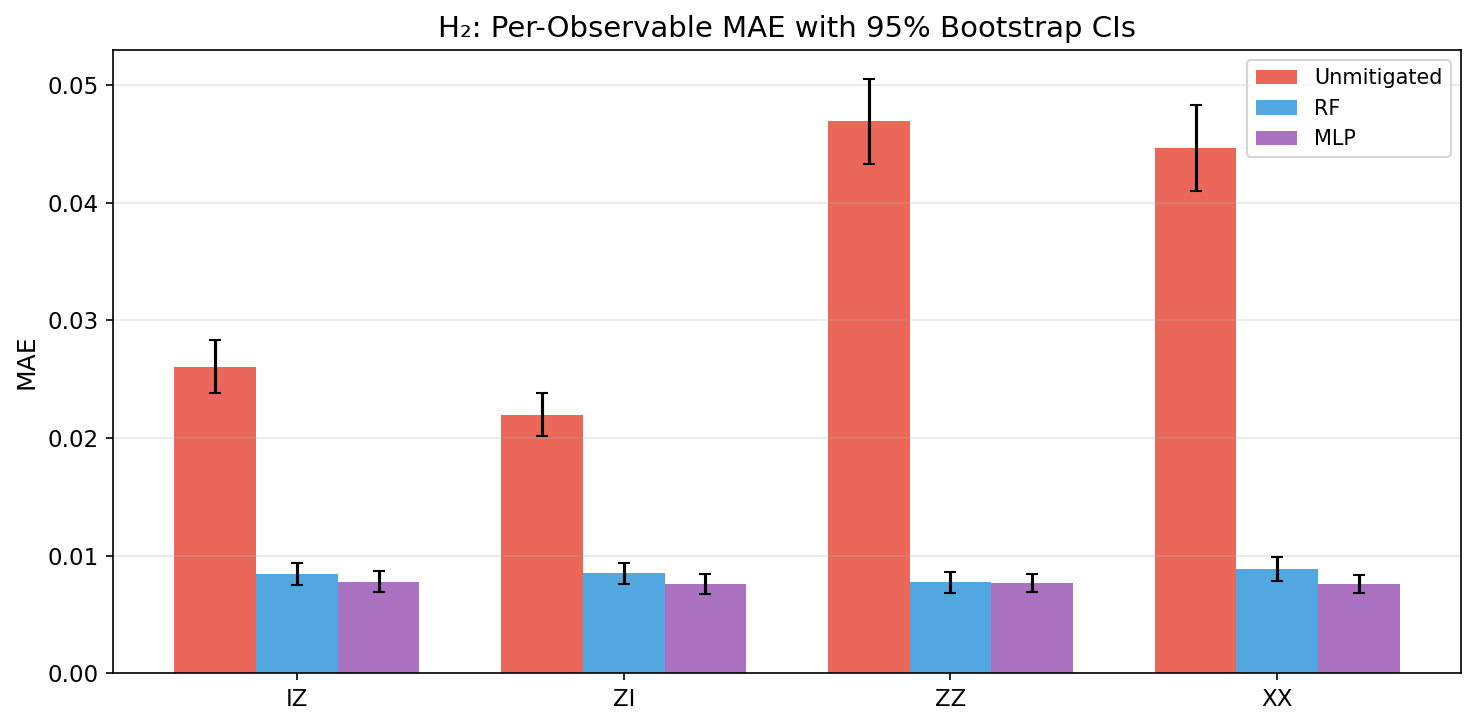

Obs             Unmitigated                   RF                  MLP
--------------------------------------------------------------------
IZ     0.0261 [0.0238,0.0284]  0.0084 [0.0075,0.0094]  0.0078 [0.0069,0.0087]
ZI     0.0220 [0.0201,0.0238]  0.0085 [0.0076,0.0094]  0.0076 [0.0068,0.0084]
ZZ     0.0469 [0.0433,0.0505]  0.0077 [0.0069,0.0086]  0.0077 [0.0070,0.0084]
XX     0.0446 [0.0410,0.0483]  0.0089 [0.0078,0.0099]  0.0076 [0.0068,0.0083]


In [44]:
obs_names, unm_maes, rf_maes_obs, mlp_maes_obs = [], [], [], []
unm_cis, rf_cis, mlp_cis = [], [], []

for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]
    ideal_vals = ideal_data[N_TRAIN:, obs_idx]
    noisy_vals = noisy_data[N_TRAIN:, obs_idx]

    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = 200
    feats = np.column_stack([
        noisy_vals, np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX), np.tile(nf, (N, 1)),
    ]).astype(np.float32)
    rf_corr = rf.predict(feats)
    
    # Get MLP predictions for this observable
    feats_sc = scaler.transform(feats)
    model_final.eval()
    with torch.no_grad():
        mlp_corr = model_final(torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()

    err_unm = np.abs(ideal_vals - noisy_vals)
    err_rf = np.abs(ideal_vals - rf_corr)
    err_mlp = np.abs(ideal_vals - mlp_corr)

    def boot_ci(errors):
        boots = [errors[rng.choice(N, size=N, replace=True)].mean() for _ in range(1000)]
        return (errors.mean() - np.percentile(boots, 2.5), np.percentile(boots, 97.5) - errors.mean())

    obs_names.append(label)
    unm_maes.append(err_unm.mean()); unm_cis.append(boot_ci(err_unm))
    rf_maes_obs.append(err_rf.mean()); rf_cis.append(boot_ci(err_rf))
    mlp_maes_obs.append(err_mlp.mean()); mlp_cis.append(boot_ci(err_mlp))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(obs_names)); w = 0.25
ax.bar(x - w, unm_maes, w, color=COLORS['unm'], alpha=0.85, label='Unmitigated',
       yerr=np.array(unm_cis).T, capsize=3)
ax.bar(x, rf_maes_obs, w, color=COLORS['rf'], alpha=0.85, label='RF',
       yerr=np.array(rf_cis).T, capsize=3)
ax.bar(x + w, mlp_maes_obs, w, color=COLORS['mlp'], alpha=0.85, label='MLP',
       yerr=np.array(mlp_cis).T, capsize=3)
ax.set_xticks(x); ax.set_xticklabels(obs_names)
ax.set_ylabel('MAE')
ax.set_title('H₂: Per-Observable MAE with 95% Bootstrap CIs')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('h2_per_observable_ci.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"Obs":<6} {"Unmitigated":>20} {"RF":>20} {"MLP":>20}')
print('-' * 68)
for i, label in enumerate(obs_names):
    u_lo, u_hi = unm_maes[i] - unm_cis[i][0], unm_maes[i] + unm_cis[i][1]
    r_lo, r_hi = rf_maes_obs[i] - rf_cis[i][0], rf_maes_obs[i] + rf_cis[i][1]
    m_lo, m_hi = mlp_maes_obs[i] - mlp_cis[i][0], mlp_maes_obs[i] + mlp_cis[i][1]
    print(f'{label:<6} {unm_maes[i]:.4f} [{u_lo:.4f},{u_hi:.4f}]  '
          f'{rf_maes_obs[i]:.4f} [{r_lo:.4f},{r_hi:.4f}]  '
          f'{mlp_maes_obs[i]:.4f} [{m_lo:.4f},{m_hi:.4f}]')

## 10. Feature Ablation Study

Noisy value only         : MAE = 0.0162  (2.2x)
+ Symplectic             : MAE = 0.0085  (4.1x)
+ Gate counts            : MAE = 0.0085  (4.1x)
+ Noise params           : MAE = 0.0084  (4.2x)


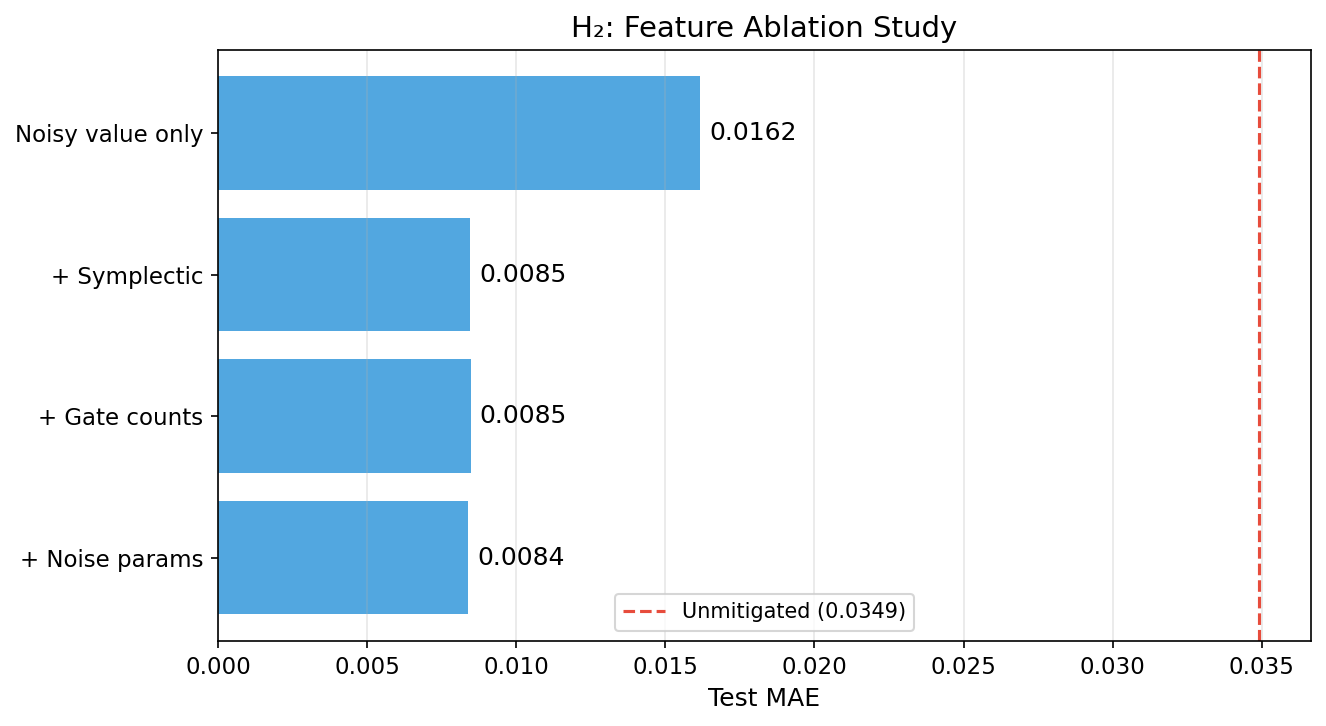

In [45]:
baseline_mae = mean_absolute_error(y_test, baseline)
ablation_configs = [
    ('Noisy value only', [0]),
    ('+ Symplectic',     [0, 1, 2, 3, 4]),
    ('+ Gate counts',    [0, 1, 2, 3, 4, 5, 6]),
    ('+ Noise params',   list(range(13))),
]

ablation_names, ablation_maes = [], []
for name, feat_idx in ablation_configs:
    rf_abl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_abl.fit(X_train[:, feat_idx], y_train)
    pred = rf_abl.predict(X_test[:, feat_idx])
    mae = mean_absolute_error(y_test, pred)
    ablation_names.append(name)
    ablation_maes.append(mae)
    print(f'{name:<25s}: MAE = {mae:.4f}  ({baseline_mae/mae:.1f}x)')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(ablation_names[::-1], ablation_maes[::-1], color=COLORS['rf'], alpha=0.85)
ax.axvline(baseline_mae, color=COLORS['unm'], linestyle='--', linewidth=1.5,
           label=f'Unmitigated ({baseline_mae:.4f})')
for bar, val in zip(bars, ablation_maes[::-1]):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
ax.set_xlabel('Test MAE')
ax.set_title('H₂: Feature Ablation Study')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('h2_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary

In [47]:
print('='*70)
print('UPDATED TABLE 1 VALUES (H₂)')
print('='*70)
print(f'Unmitigated MAE: {mae_unm:.4f}  (95% CI: [{lo_unm:.4f}, {hi_unm:.4f}])')
print(f'RF MAE:          {mae_rf:.4f}  (95% CI: [{lo_rf:.4f}, {hi_rf:.4f}])')
print(f'MLP MAE:         {mlp_mae_mean:.4f} ± {mlp_mae_std:.4f}  (mean ± std, {N_MLP_SEEDS} seeds)')
print(f'MLP median seed: {mae_mlp:.4f}  (95% CI: [{lo_mlp:.4f}, {hi_mlp:.4f}])')
print()
print(f'Energy MAE — Unmitigated: {e_mae_unm:.5f} Ha  [{e_lo_unm:.5f}, {e_hi_unm:.5f}]')
print(f'Energy MAE — RF:          {e_mae_rf:.5f} Ha  [{e_lo_rf:.5f}, {e_hi_rf:.5f}]')
print(f'Energy MAE — MLP:         {e_mae_mlp:.5f} Ha  [{e_lo_mlp:.5f}, {e_hi_mlp:.5f}]')
print()
if ci_lower > 0:
    print('RF vs MLP: RF significantly better')
elif ci_upper < 0:
    print('RF vs MLP: MLP significantly better')
else:
    print('RF vs MLP: difference not significant')
print(f'  Diff 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
print()
print(f'RF overfitting: {test_mae_rf/train_mae_rf:.2f}x')
print(f'MLP overfitting: {test_mae_mlp/train_mae_mlp:.2f}x')
print()
print('ABLATION KEY FINDING:')
print(f'  Noisy value only: MAE = {ablation_maes[0]:.4f} ({baseline_mae/ablation_maes[0]:.1f}x)')
print(f'  + Symplectic:     MAE = {ablation_maes[1]:.4f} ({baseline_mae/ablation_maes[1]:.1f}x) ← critical')
print(f'  + Gate counts:    MAE = {ablation_maes[2]:.4f} (no change)')
print(f'  + Noise params:   MAE = {ablation_maes[3]:.4f} (negligible)')

UPDATED TABLE 1 VALUES (H₂)
Unmitigated MAE: 0.0349  (95% CI: [0.0333, 0.0365])
RF MAE:          0.0084  (95% CI: [0.0079, 0.0088])
MLP MAE:         0.0076 ± 0.0001  (mean ± std, 5 seeds)
MLP median seed: 0.0077  (95% CI: [0.0072, 0.0081])

Energy MAE — Unmitigated: 0.01555 Ha  [0.01430, 0.01681]
Energy MAE — RF:          0.00461 Ha  [0.00406, 0.00518]
Energy MAE — MLP:         0.00402 Ha  [0.00354, 0.00455]

RF vs MLP: MLP significantly better
  Diff 95% CI: [-0.0013, -0.0001]

RF overfitting: 2.49x
MLP overfitting: 1.04x

ABLATION KEY FINDING:
  Noisy value only: MAE = 0.0162 (2.2x)
  + Symplectic:     MAE = 0.0085 (4.1x) ← critical
  + Gate counts:    MAE = 0.0085 (no change)
  + Noise params:   MAE = 0.0084 (negligible)
